# 00 | Sample Selection

## Section 1 - Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import astropy.units as u

In [2]:
!pip install astroquery
from astroquery.sdss import SDSS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 58.7 MB/s eta 0:00:00


## Querying SDSS via astroquery

In [5]:
query = """
SELECT TOP 3000
  p.objid, p.ra, p.dec, p.petroRad_r, s.z, s.class, p.modelMag_u, p.modelMag_g, p.modelMag_r, p.modelMag_i, p.modelMag_z, p.modelMagErr_u, p.modelMagErr_g, p.modelMagErr_r, p.modelMagErr_i, p.modelMagErr_z, s.snMedian
FROM PhotoObj AS p
JOIN SpecObj AS s ON p.objid = s.bestObjID
WHERE p.clean = 1 AND s.class = 'GALAXY' AND s.z BETWEEN 0.02 AND 0.25
"""

result = SDSS.query_sql(query)
result

objid,ra,dec,petroRad_r,z,class,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,modelMagErr_u,modelMagErr_g,modelMagErr_r,modelMagErr_i,modelMagErr_z,snMedian
uint64,float64,float64,float64,float64,str6,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1237648720135455441,130.762871797005,-1.01372747013554,2.947396,0.1520929,GALAXY,21.24462,19.79819,18.80876,18.41234,18.04467,0.1834108,0.02755986,0.01655954,0.01773511,0.04547602,5.8306
1237648720135455545,130.749440651657,-0.954400385635648,2.488183,0.1805459,GALAXY,22.08829,20.70564,20.2384,19.99213,19.82723,0.2627743,0.04023096,0.0376355,0.04612778,0.1471242,2.72886
1237648720142008515,145.821638182128,-0.846601885046273,5.089256,0.06770252,GALAXY,20.05802,18.35321,17.54987,17.15258,16.86671,0.07613668,0.01041044,0.007362394,0.007729872,0.02027678,10.20291
1237648720142008580,145.818101273901,-0.878973095843891,5.040677,0.2045784,GALAXY,20.68866,18.55757,17.21298,16.66901,16.32187,0.156786,0.01448036,0.006869894,0.006444947,0.01518092,11.13883
1237648720142073942,145.853157594108,-0.997063559085189,3.825139,0.1448017,GALAXY,20.61629,18.63789,17.54523,17.09494,16.7594,0.09903547,0.01131102,0.00669298,0.006630015,0.01533615,13.57714
1237648720142073959,145.892309469118,-1.02264988945927,4.531637,0.153699,GALAXY,20.39159,18.22442,17.0139,16.50938,16.11972,0.09698515,0.009496787,0.005328335,0.005128764,0.0110142,16.28147
1237648720142270656,146.432797355117,-0.987378009062472,3.590598,0.1404723,GALAXY,20.43741,18.42003,17.31446,16.85592,16.49146,0.08192131,0.009216757,0.005610146,0.005560924,0.01189375,15.94299
1237648720142336185,146.51281767756,-0.84578295276744,9.461358,0.06490172,GALAXY,17.37162,16.17903,15.5015,15.05806,14.78616,0.01564752,0.003873545,0.003227174,0.003246894,0.006836015,24.35292
1237648720142336237,146.571322012569,-0.957206943582653,8.935108,0.06518305,GALAXY,18.5427,17.0509,16.25521,15.79538,15.45037,0.0293057,0.00538617,0.004148107,0.00415204,0.008886985,16.72298


In [6]:
df = result.to_pandas()
df.head()

,objid,ra,dec,petroRad_r,z,class,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,modelMagErr_u,modelMagErr_g,modelMagErr_r,modelMagErr_i,modelMagErr_z,snMedian
0,1237648720135455441,130.762872,-1.013727,2.947396,0.152093,GALAXY,21.24462,19.79819,18.80876,18.41234,18.04467,0.183411,0.027560,0.016560,0.017735,0.045476,5.83060
1,1237648720135455545,130.749441,-0.954400,2.488183,0.180546,GALAXY,22.08829,20.70564,20.23840,19.99213,19.82723,0.262774,0.040231,0.037636,0.046128,0.147124,2.72886
2,1237648720142008515,145.821638,-0.846602,5.089256,0.067703,GALAXY,20.05802,18.35321,17.54987,17.15258,16.86671,0.076137,0.010410,0.007362,0.007730,0.020277,10.20291
3,1237648720142008580,145.818101,-0.878973,5.040677,0.204578,GALAXY,20.68866,18.55757,17.21298,16.66901,16.32187,0.156786,0.014480,0.006870,0.006445,0.015181,11.13883
4,1237648720142073942,145.853158,-0.997064,3.825139,0.144802,GALAXY,20.61629,18.63789,17.54523,17.09494,16.75940,0.099035,0.011311,0.006693,0.006630,0.015336,13.57714


In [7]:
df

,objid,ra,dec,petroRad_r,z,class,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,modelMagErr_u,modelMagErr_g,modelMagErr_r,modelMagErr_i,modelMagErr_z,snMedian
0,1237648720135455441,130.762872,-1.013727,2.947396,0.152093,GALAXY,21.24462,19.79819,18.80876,18.41234,18.04467,0.183411,0.027560,0.016560,0.017735,0.045476,5.830600
1,1237648720135455545,130.749441,-0.954400,2.488183,0.180546,GALAXY,22.08829,20.70564,20.23840,19.99213,19.82723,0.262774,0.040231,0.037636,0.046128,0.147124,2.728860
2,1237648720142008515,145.821638,-0.846602,5.089256,0.067703,GALAXY,20.05802,18.35321,17.54987,17.15258,16.86671,0.076137,0.010410,0.007362,0.007730,0.020277,10.202910
3,1237648720142008580,145.818101,-0.878973,5.040677,0.204578,GALAXY,20.68866,18.55757,17.21298,16.66901,16.32187,0.156786,0.014480,0.006870,0.006445,0.015181,11.138830
4,1237648720142073942,145.853158,-0.997064,3.825139,0.144802,GALAXY,20.61629,18.63789,17.54523,17.09494,16.75940,0.099035,0.011311,0.006693,0.006630,0.015336,13.577140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,1237657630064574650,179.327424,52.792071,5.823124,0.067991,GALAXY,18.98433,17.80638,17.31197,16.98639,16.83671,0.041341,0.008564,0.007606,0.008962,0.023098,8.241838
2996,1237657630064574656,179.331938,52.875930,2.725636,0.147234,GALAXY,20.21254,18.40500,17.35322,16.90771,16.54432,0.068148,0.008281,0.005440,0.005531,0.010661,16.149260
2997,1237657630064640062,179.477975,52.986707,6.662117,0.092054,GALAXY,19.75090,18.15018,17.30500,16.81382,16.49722,0.072051,0.009179,0.007093,0.006924,0.015404,8.178138
2998,1237657630064705676,179.785663,52.973089,4.662381,0.066440,GALAXY,18.47779,17.03031,16.41874,15.98532,15.78269,0.023839,0.004537,0.003878,0.003971,0.007895,20.194750


## Quality Cuts

In [8]:
cuts = (df['snMedian'] > 10) & (df['petroRad_r'] > 3) & (df['modelMag_r'] < 17.77)
df_clean = df[cuts]

In [9]:
print(f"Before cuts: {len(df)}")
print(f"After cuts: {len(df_clean)}")
print(f"Fraction of targets retained: {len(df_clean)/len(df):.2f}")

Before cuts: 3000
After cuts: 1817
Fraction of targets retained: 0.61


## Plotting

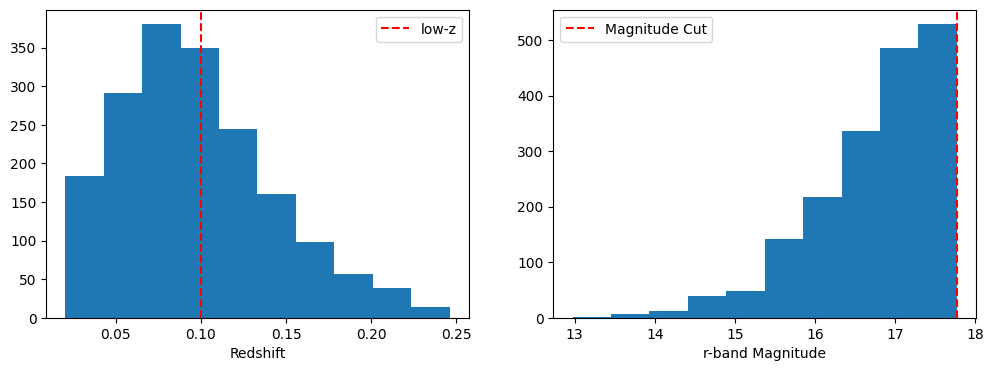

In [10]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

axes[0].hist(df_clean['z'])
axes[0].set_xlabel('Redshift')
axes[0].axvline(0.1, color='red', linestyle='--', label='low-z')
axes[0].legend()

axes[1].hist(df_clean['modelMag_r'])
axes[1].set_xlabel('r-band Magnitude')
axes[1].axvline(17.77, color='red', linestyle='--', label='Magnitude Cut')
axes[1].legend()


In [11]:
df_clean['low_z'] = df_clean['z'] < 0.1
df_clean

/tmp/ipykernel_635/1020378291.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['low_z'] = df_clean['z'] < 0.1


,objid,ra,dec,petroRad_r,z,class,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,modelMagErr_u,modelMagErr_g,modelMagErr_r,modelMagErr_i,modelMagErr_z,snMedian,low_z
2,1237648720142008515,145.821638,-0.846602,5.089256,0.067703,GALAXY,20.05802,18.35321,17.54987,17.15258,16.86671,0.076137,0.010410,0.007362,0.007730,0.020277,10.20291,True
3,1237648720142008580,145.818101,-0.878973,5.040677,0.204578,GALAXY,20.68866,18.55757,17.21298,16.66901,16.32187,0.156786,0.014480,0.006870,0.006445,0.015181,11.13883,False
4,1237648720142073942,145.853158,-0.997064,3.825139,0.144802,GALAXY,20.61629,18.63789,17.54523,17.09494,16.75940,0.099035,0.011311,0.006693,0.006630,0.015336,13.57714,False
5,1237648720142073959,145.892309,-1.022650,4.531637,0.153699,GALAXY,20.39159,18.22442,17.01390,16.50938,16.11972,0.096985,0.009497,0.005328,0.005129,0.011014,16.28147,False
6,1237648720142270656,146.432797,-0.987378,3.590598,0.140472,GALAXY,20.43741,18.42003,17.31446,16.85592,16.49146,0.081921,0.009217,0.005610,0.005561,0.011894,15.94299,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2988,1237657630064574618,179.185816,52.784357,4.921969,0.068700,GALAXY,18.95556,17.50044,16.79793,16.44113,16.17238,0.033074,0.005400,0.004432,0.004702,0.010381,17.45897,True
2990,1237651800162304205,154.437788,-0.732376,4.367133,0.085777,GALAXY,19.10930,17.93893,17.39034,17.01727,16.83489,0.040881,0.008041,0.008367,0.007289,0.021053,12.43208,True
2994,1237651800162238663,154.266041,-0.631991,4.272007,0.050029,GALAXY,19.45912,17.73841,16.95952,16.55442,16.25257,0.046473,0.006473,0.005202,0.004929,0.011036,18.32790,True
2998,1237657630064705676,179.785663,52.973089,4.662381,0.066440,GALAXY,18.47779,17.03031,16.41874,15.98532,15.78269,0.023839,0.004537,0.003878,0.003971,0.007895,20.19475,True


In [12]:
df_clean = df_clean.reset_index(drop=True)
df_clean

,objid,ra,dec,petroRad_r,z,class,modelMag_u,modelMag_g,modelMag_r,modelMag_i,modelMag_z,modelMagErr_u,modelMagErr_g,modelMagErr_r,modelMagErr_i,modelMagErr_z,snMedian,low_z
0,1237648720142008515,145.821638,-0.846602,5.089256,0.067703,GALAXY,20.05802,18.35321,17.54987,17.15258,16.86671,0.076137,0.010410,0.007362,0.007730,0.020277,10.20291,True
1,1237648720142008580,145.818101,-0.878973,5.040677,0.204578,GALAXY,20.68866,18.55757,17.21298,16.66901,16.32187,0.156786,0.014480,0.006870,0.006445,0.015181,11.13883,False
2,1237648720142073942,145.853158,-0.997064,3.825139,0.144802,GALAXY,20.61629,18.63789,17.54523,17.09494,16.75940,0.099035,0.011311,0.006693,0.006630,0.015336,13.57714,False
3,1237648720142073959,145.892309,-1.022650,4.531637,0.153699,GALAXY,20.39159,18.22442,17.01390,16.50938,16.11972,0.096985,0.009497,0.005328,0.005129,0.011014,16.28147,False
4,1237648720142270656,146.432797,-0.987378,3.590598,0.140472,GALAXY,20.43741,18.42003,17.31446,16.85592,16.49146,0.081921,0.009217,0.005610,0.005561,0.011894,15.94299,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1812,1237657630064574618,179.185816,52.784357,4.921969,0.068700,GALAXY,18.95556,17.50044,16.79793,16.44113,16.17238,0.033074,0.005400,0.004432,0.004702,0.010381,17.45897,True
1813,1237651800162304205,154.437788,-0.732376,4.367133,0.085777,GALAXY,19.10930,17.93893,17.39034,17.01727,16.83489,0.040881,0.008041,0.008367,0.007289,0.021053,12.43208,True
1814,1237651800162238663,154.266041,-0.631991,4.272007,0.050029,GALAXY,19.45912,17.73841,16.95952,16.55442,16.25257,0.046473,0.006473,0.005202,0.004929,0.011036,18.32790,True
1815,1237657630064705676,179.785663,52.973089,4.662381,0.066440,GALAXY,18.47779,17.03031,16.41874,15.98532,15.78269,0.023839,0.004537,0.003878,0.003971,0.007895,20.19475,True


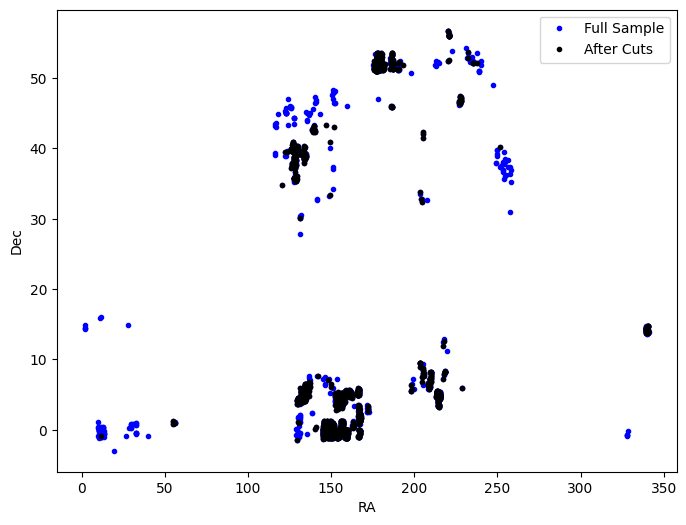

In [13]:
plt.figure(figsize=(8,6))
plt.plot(df['ra'], df['dec'], 'b.', label='Full Sample')

plt.plot(df_clean['ra'], df_clean['dec'], 'k.', label="After Cuts")
plt.xlabel('RA')
plt.ylabel('Dec')
plt.legend()

### Export panda dataframe to csv

In [14]:
df_clean.to_csv("galaxy_sample.csv", index=False)